In [1]:
import sys
sys.path.append('utils')
sys.path.append('models/ATPDrain_Etotfix')
sys.path.append('models')

from cobrak_main_workflows import run_cobrak_basic
from analysis_functions import compute_total_enzyme_weight, compute_grouped_enzyme_mass, append_analysis_rows
from plotting_functions import plot_enzyme_analysis

from toy_model_full_Wcomp_wo_bio import initialize_model_w_comp
from toy_model_full_WOcomp_wo_bio import initialize_model_wo_comp

In [2]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import inspect

## dG0_transporter × Growth Rate

**Parameters:**
- Growth rates
- Transporter dG0
- 4 scenarios: comp+/comp- × ATP_con+/ATP_con-


In [3]:
import toy_params_yeast_weights_bioatp32_AllDefkm as extra_params

In [4]:
objective_target="ATP_Consumption"
objective_sense=1

#growth_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
#dG0_transport_values = [-10, -5, 0, 5, 10]

growth_grid = [0.1, 0.2, 0.4, 0.6]
dG0_transport_values = [-10, -5, 0, 5]


kcat = 1e20
pop_size = 128
evolution_num_gens = 60
uptake_tol = 0.1

total_runs = len(growth_grid) * len(dG0_transport_values) * 4
print(f"Total optimization runs: {total_runs}")
print(f"Growth rates: {growth_grid}")
print(f"Transporter dG0 values: {dG0_transport_values}")

Total optimization runs: 64
Growth rates: [0.1, 0.2, 0.4, 0.6]
Transporter dG0 values: [-10, -5, 0, 5]


In [ ]:
sig = inspect.signature(initialize_model_w_comp)
valid_params = set(sig.parameters.keys())

sig_wo = inspect.signature(initialize_model_wo_comp)
valid_params_wo = set(sig_wo.parameters.keys())

### Scenario 1: With Compartment, without ATP constraint

In [ ]:
results_grid1 = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params
            }
            auto_kwargs["k_cat_transport"] = kcat
            auto_kwargs["atp_concentration_constraint"] = False
            auto_kwargs["atp_m_concentration_constraint"] = False
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model = initialize_model_w_comp(**auto_kwargs)

            print(f"[comp/noATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

### Scenario 2: With Compartment, with ATP constraint

In [ ]:
results_grid1_w_constraint = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params
            }
            auto_kwargs["k_cat_transport"] = kcat
            auto_kwargs["atp_concentration_constraint"] = True
            auto_kwargs["atp_m_concentration_constraint"] = True
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model_w_constraint = initialize_model_w_comp(**auto_kwargs)

            print(f"[comp/ATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model_w_constraint,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1_w_constraint[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

### Scenario 3: Without Compartment, with ATP constraint

In [ ]:
results_grid1_wo = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params_wo
            }
            auto_kwargs["atp_concentration_constraint"] = True
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model_wo = initialize_model_wo_comp(**auto_kwargs)

            print(f"[nocomp/ATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model_wo,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1_wo[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

### Scenario 4: Without Compartment, without ATP constraint

In [ ]:
results_grid1_wo_wo_atpconstraint = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params_wo
            }
            auto_kwargs["atp_concentration_constraint"] = False
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model_wo_wo_atpconstraint = initialize_model_wo_comp(**auto_kwargs)

            print(f"[nocomp/noATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model_wo_wo_atpconstraint,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1_wo_wo_atpconstraint[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

## Convert results to DataFrames

In [28]:
def flatten_results(results_dict, scenario_name, atp_scenario=None, compartment_scenario=None):
    """Convert nested defaultdict to flat list of dicts."""
    rows = []
    for growth_val, dg0_dict in results_dict.items():
        for dg0_val, result in dg0_dict.items():
            row = {
                'growth': float(growth_val),
                'transport_dG0': dg0_val,
                'scenario': scenario_name,
                'atp_scenario': atp_scenario,
                'compartment_scenario': compartment_scenario,
                'prot_pool_delivery': result.get('prot_pool_delivery', None),
                'Glycolysis_flux': result.get('Glycolysis', None),
                'Respiration_flux': result.get('Respiration', None),
                'Overflow_flux': result.get('Overflow', None),
                'ATP_Consumption': result.get('ATP_Consumption', None),
                'EX_S_flux': result.get('EX_S', None),
                'EX_C_flux': result.get('EX_C', None),
                'EX_P_flux': result.get('EX_P', None),
                'EX_B_flux': result.get('EX_B', None),
                'x_ATP': result.get('x_ATP', None),
                'x_ADP': result.get('x_ADP', None),
            }
            rows.append(row)
    return pd.DataFrame(rows)

df_comp = flatten_results(results_grid1, 'comp_noATP', atp_scenario="noConstraint", compartment_scenario="comp")
df_comp_atp = flatten_results(results_grid1_w_constraint, 'comp_ATP', atp_scenario="withConstraint", compartment_scenario="comp")
df_nocomp_atp = flatten_results(results_grid1_wo, 'nocomp_ATP', atp_scenario="withConstraint", compartment_scenario="nocomp")
df_nocomp = flatten_results(results_grid1_wo_wo_atpconstraint, 'nocomp_noATP', atp_scenario="noConstraint", compartment_scenario="nocomp")

df_all = pd.concat([df_comp, df_comp_atp, df_nocomp_atp, df_nocomp], ignore_index=True)

print(f"Total rows: {len(df_all)}")
print(f"Unique growth rates: {sorted(df_all['growth'].unique())}")
print(f"Unique dG0 values: {sorted(df_all['transport_dG0'].unique())}")
print(f"Scenarios: {df_all['scenario'].unique()}")
print()
print(df_all[['growth', 'transport_dG0', 'scenario', 'prot_pool_delivery']].to_string(index=False))

Total rows: 64
Unique growth rates: [np.float64(0.1), np.float64(0.2), np.float64(0.4), np.float64(0.6)]
Unique dG0 values: [np.int64(-10), np.int64(-5), np.int64(0), np.int64(5)]
Scenarios: ['comp_noATP' 'comp_ATP' 'nocomp_ATP' 'nocomp_noATP']

 growth  transport_dG0     scenario  prot_pool_delivery
    0.1            -10   comp_noATP            0.100000
    0.1             -5   comp_noATP            0.100000
    0.1              0   comp_noATP            0.100000
    0.1              5   comp_noATP            0.100000
    0.2            -10   comp_noATP            0.200000
    0.2             -5   comp_noATP            0.200000
    0.2              0   comp_noATP            0.200000
    0.2              5   comp_noATP            0.200000
    0.4            -10   comp_noATP            0.400000
    0.4             -5   comp_noATP            0.400000
    0.4              0   comp_noATP            0.400000
    0.4              5   comp_noATP            0.400000
    0.6            -10   c

## Compute ATP consumption - compartment advantage

Best condition (max ATP advantage):


,growth,transport_dG0,atp_scenario,ATP_comp,ATP_nocomp,advantage,advantage_rel
28,0.6,-10,withConstraint,273.037253,117.453815,155.583437,1.324635


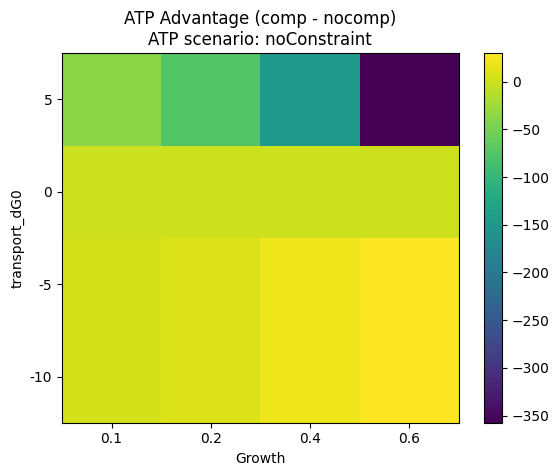

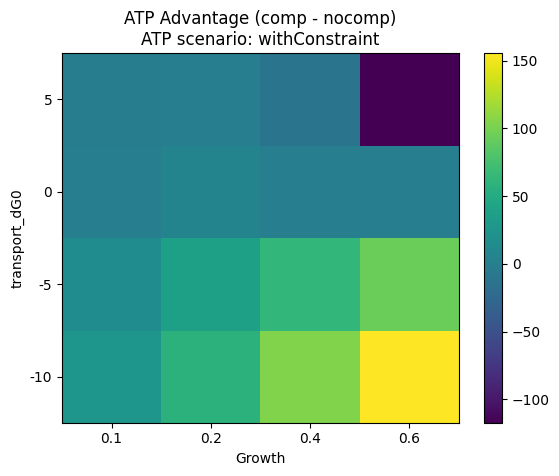

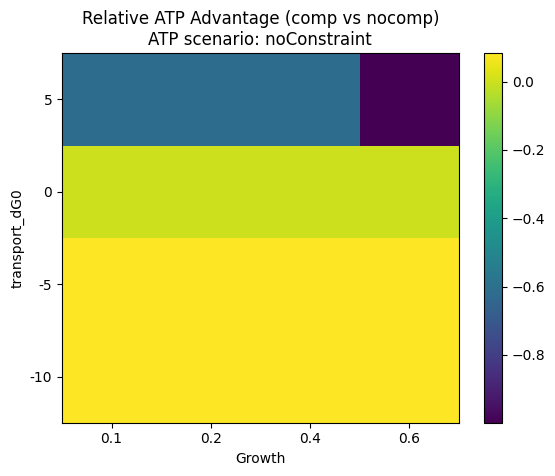

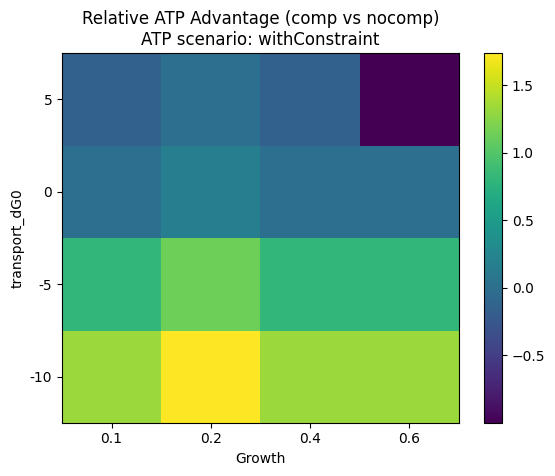

Scenario summary:


,atp_scenario,mean,min,max,count
0,noConstraint,-30.397654,-357.380299,29.765578,16
1,withConstraint,26.749790,-117.184994,155.583437,16


,atp_scenario,mean,min,max,count
0,noConstraint,-30.397654,-357.380299,29.765578,16
1,withConstraint,26.749790,-117.184994,155.583437,16


In [ ]:
adv_df = compute_compartment_advantage(df_all)

# best condition
best_idx = adv_df["advantage"].idxmax()
best_row = adv_df.loc[best_idx]

best_table = pd.DataFrame([best_row[[
    "growth",
    "transport_dG0",
    "atp_scenario",
    "ATP_comp",
    "ATP_nocomp",
    "advantage"
]]])

print("Best condition (max ATP advantage):")
display(best_table)

#heatmaps
for scenario, sub in adv_df.groupby("atp_scenario"):

    pivot = sub.pivot_table(
        index="transport_dG0",
        columns="growth",
        values="advantage"
    )

    pivot = pivot.reindex(
        index=sorted(pivot.index),
        columns=sorted(pivot.columns)
    )

    plt.figure()
    plt.imshow(pivot.values, aspect="auto", origin="lower")

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.title(f"ATP Advantage (comp - nocomp)\nATP scenario: {scenario}")
    plt.xlabel("Growth")
    plt.ylabel("transport_dG0")
    plt.colorbar()
    plt.show()



summary = adv_df.groupby("atp_scenario")["advantage"].agg(
    ["mean", "min", "max", "count"]
).reset_index()

print("Scenario summary:")
display(summary)

summary

## Plotting

### ATP Consumption vs growth rate (by dG0)

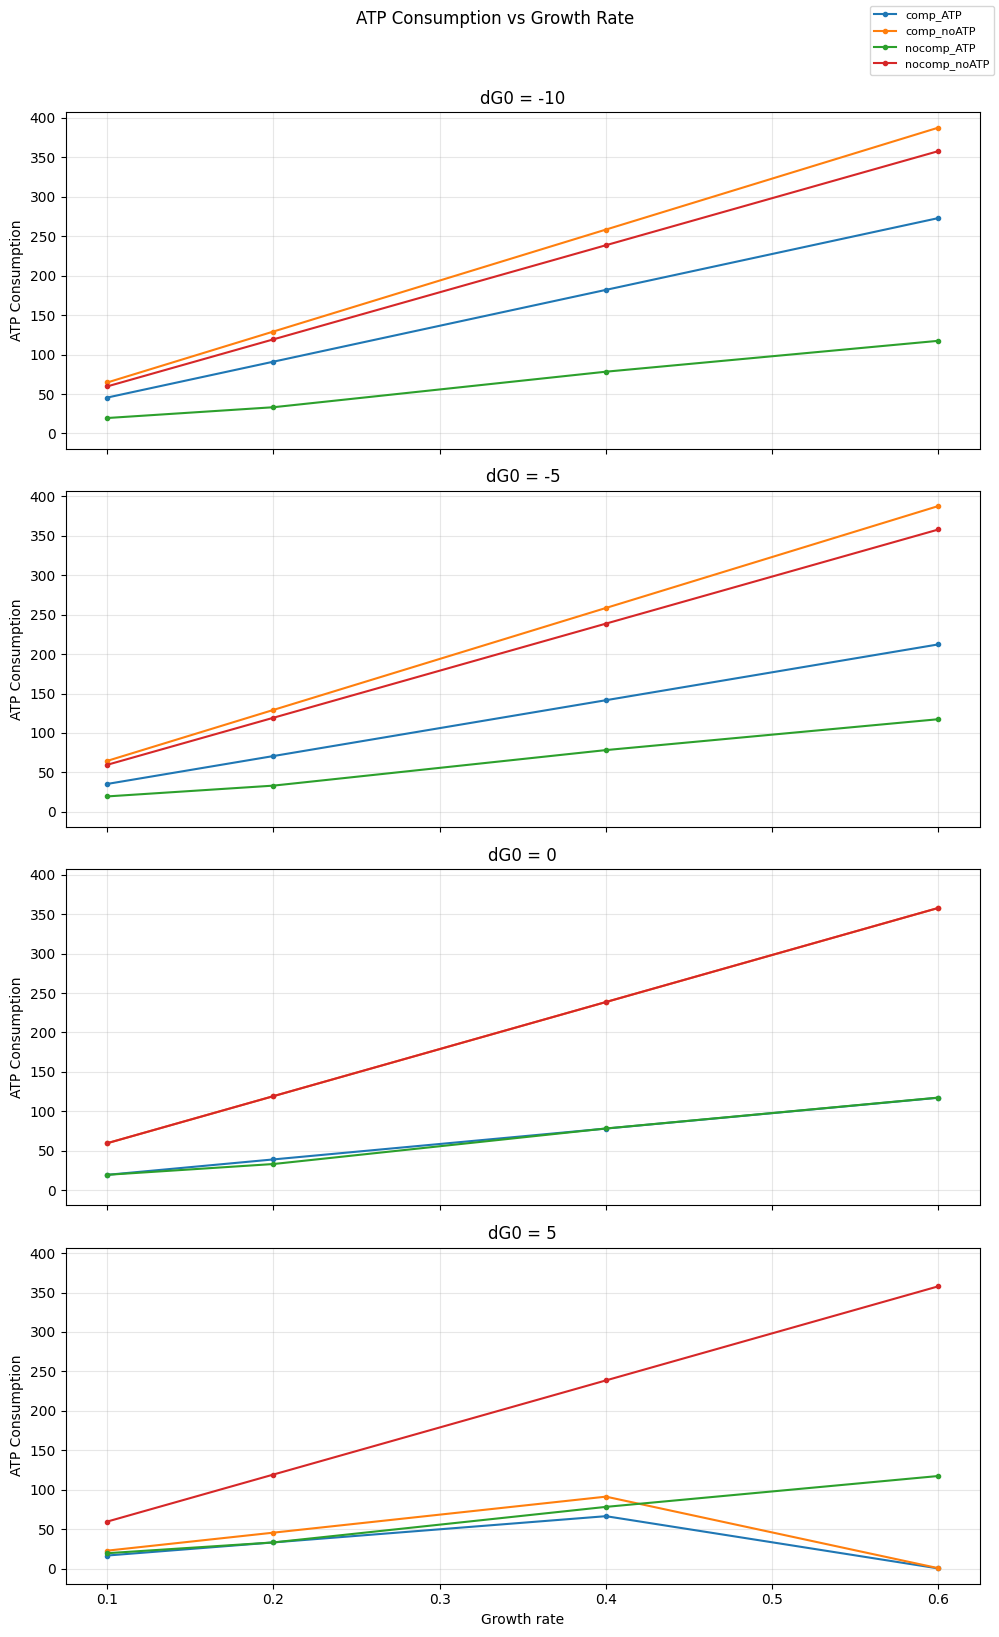

In [ ]:
plot_cost_vs_growth_by_dg0(df_all)

### ATP Consumption avantage heatmap (growth × dG0), different visualization

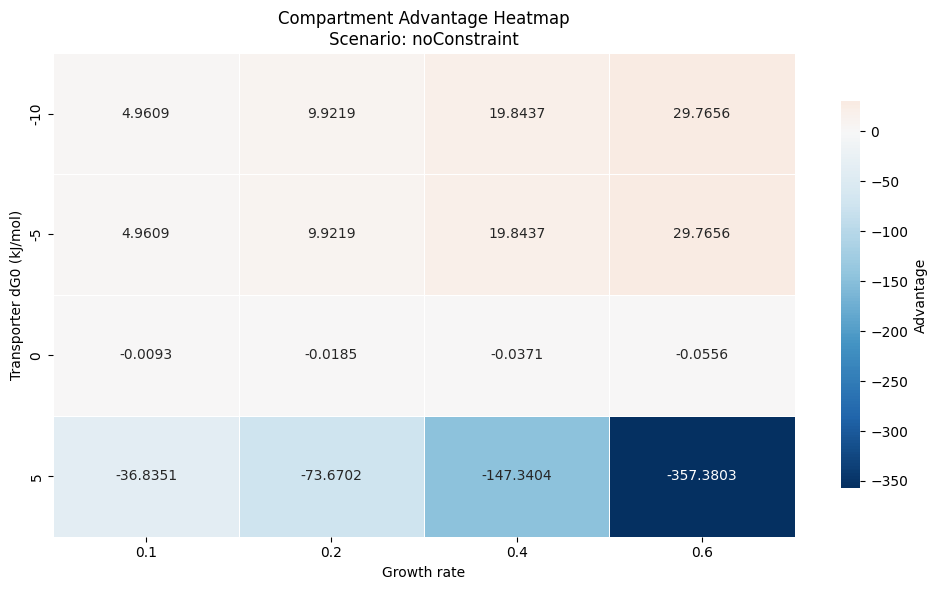

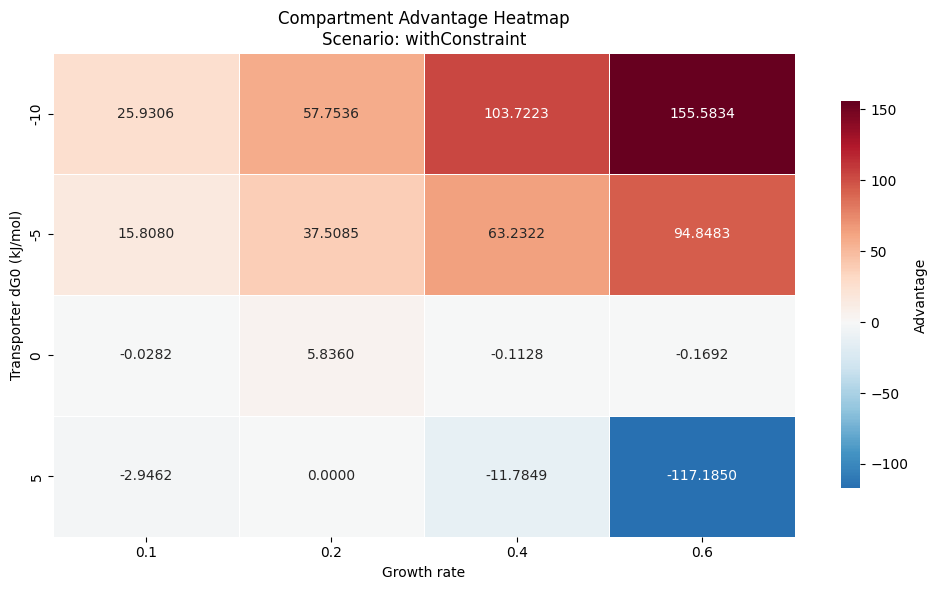

In [ ]:
plot_advantage_heatmap(adv_df)

### ATP/ADP ratio vs growth rate (by dG0)

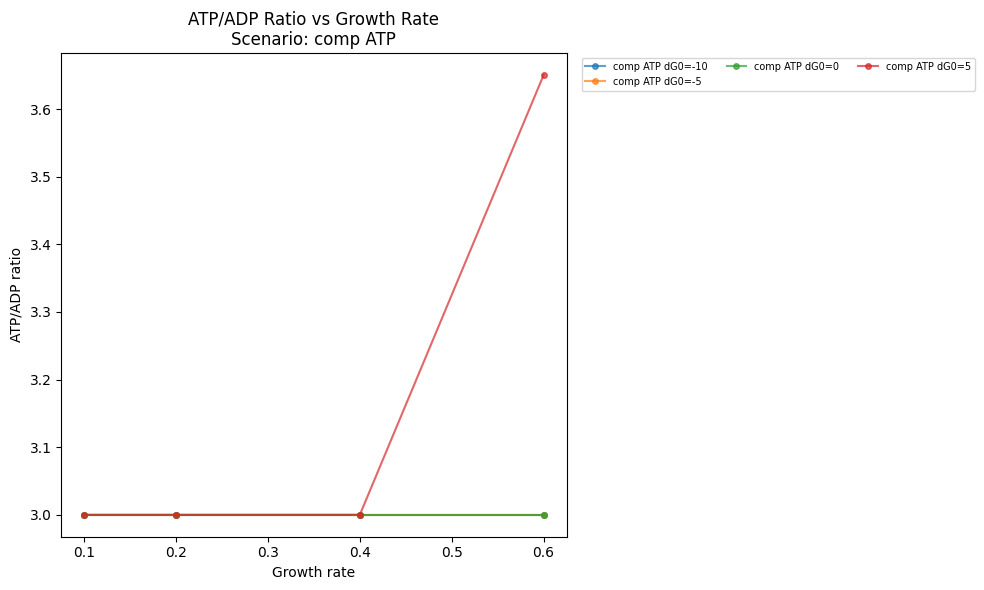

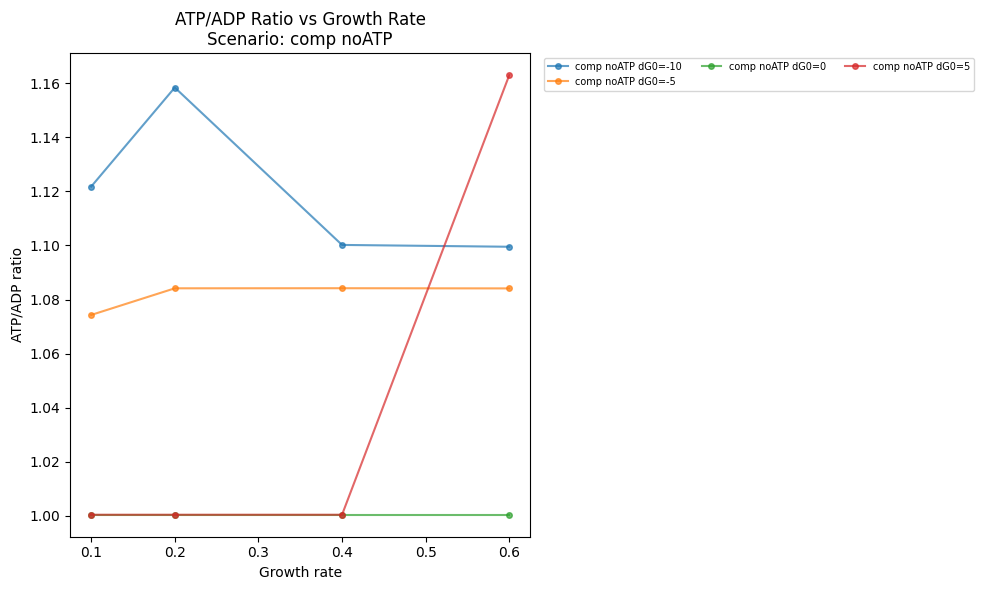

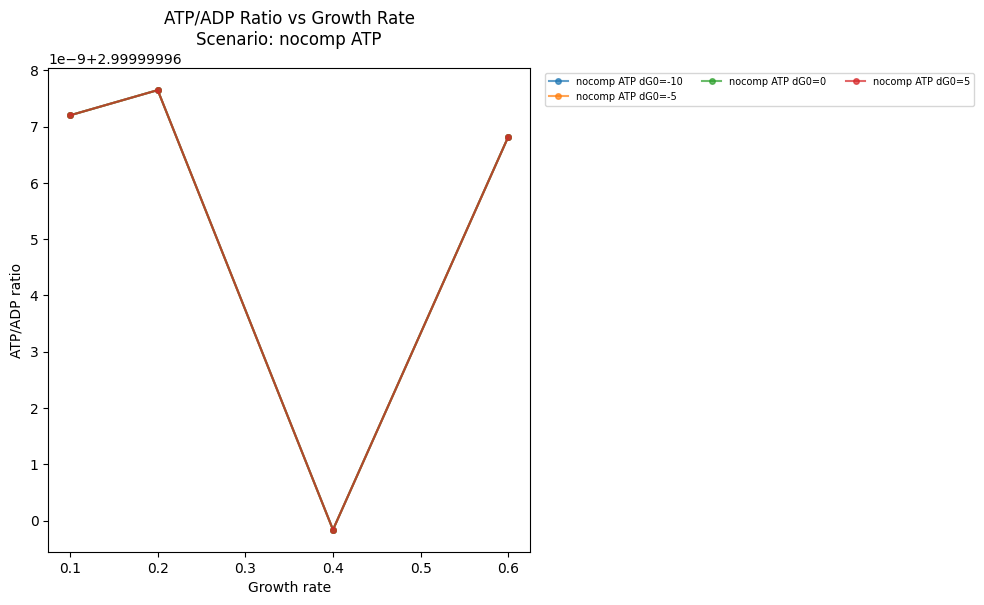

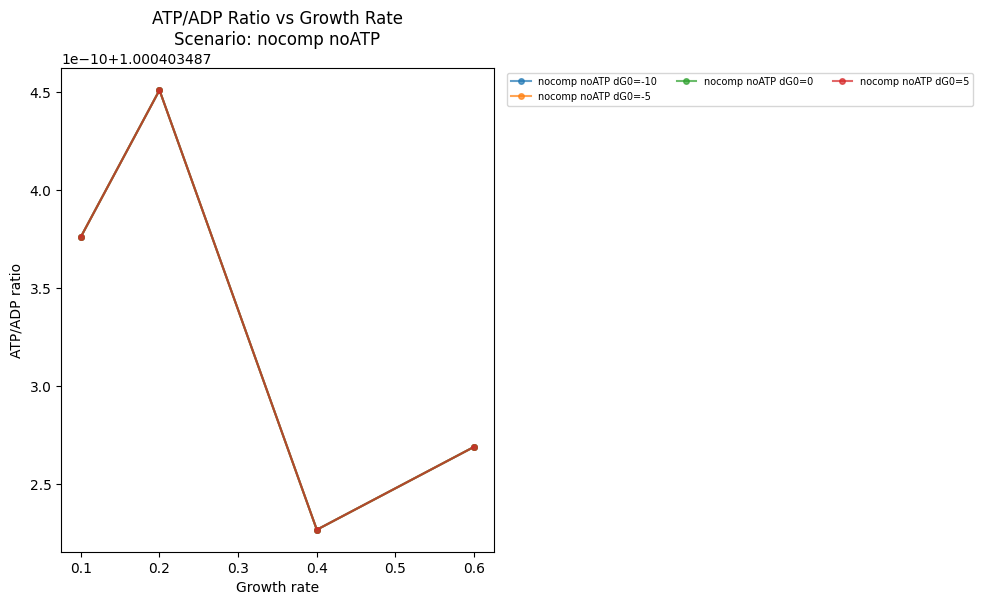

In [ ]:
plot_atp_adp_ratio_vs_growth(df_all)

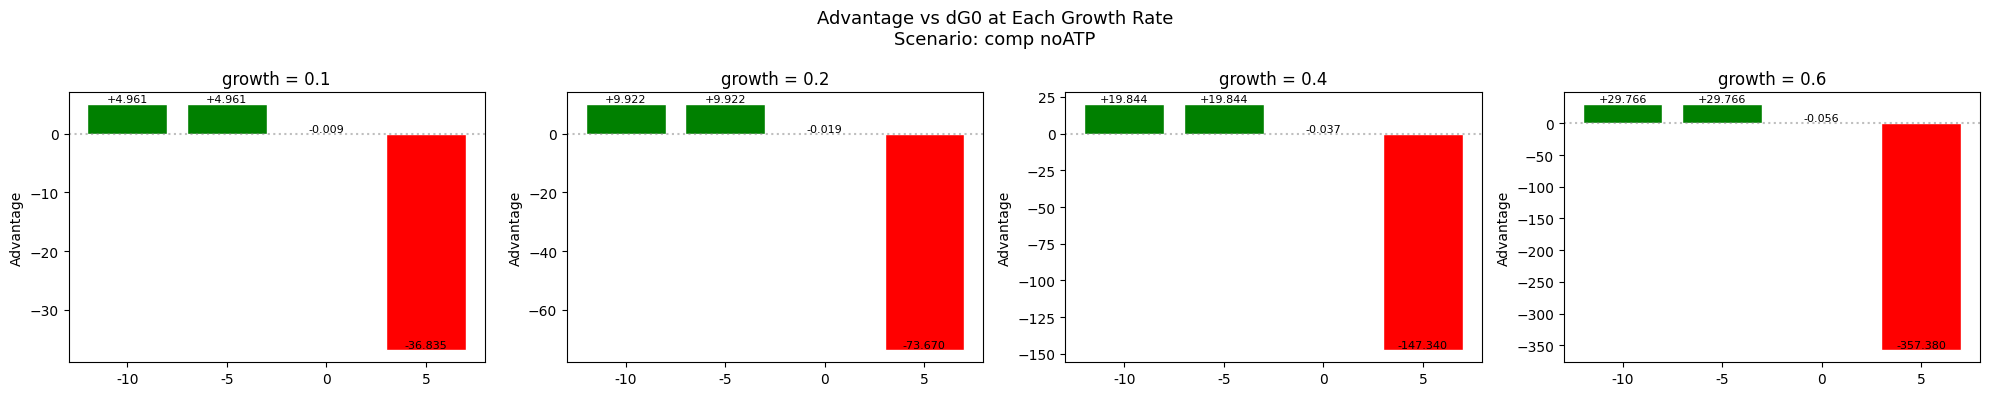

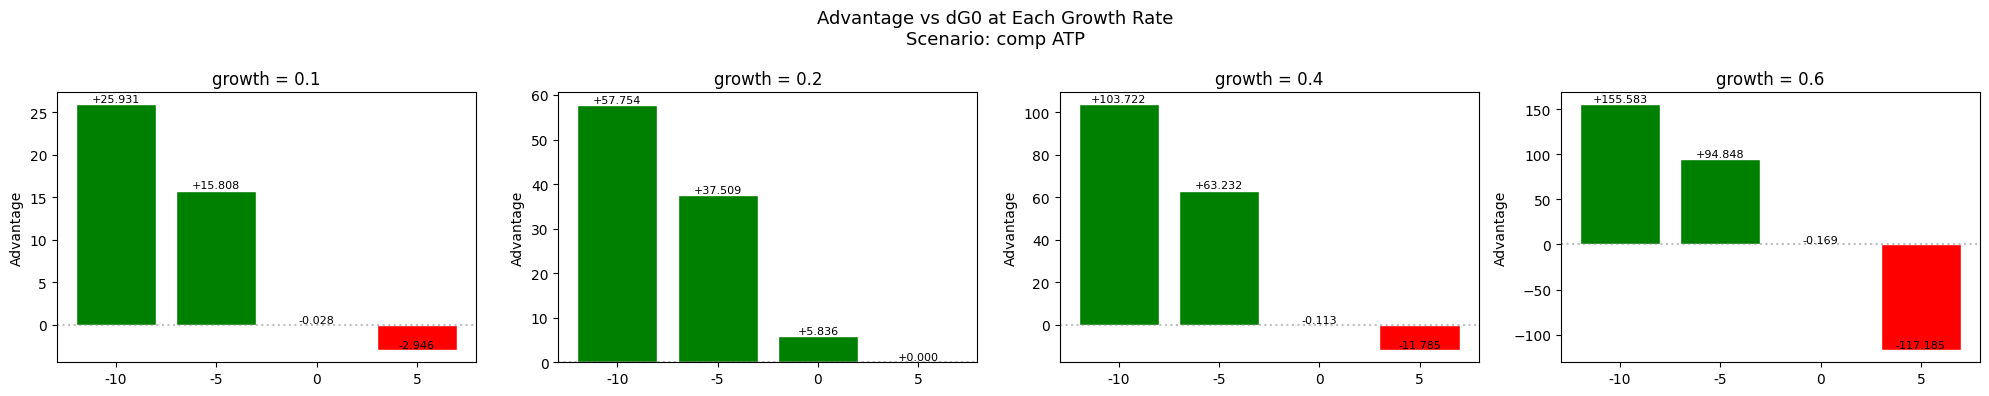

In [ ]:


plot_dg0_effect_by_growth(adv_df)

### Effect on fluxes (compartment with constraint)

In [ ]:
df_for_plot = df_comp_atp.copy()
print("DataFrame for flux analysis (comp_ATP scenario):")
print(df_for_plot[['growth', 'transport_dG0', 'prot_pool_delivery',
                    'Glycolysis_flux', 'Respiration_flux', 'Overflow_flux']].to_string(index=False))

DataFrame for enzyme analysis (comp_ATP scenario):
 growth  transport_dG0  prot_pool_delivery  Glycolysis_flux  Respiration_flux  Overflow_flux
    0.1            -10            0.100000         7.584369          7.584369  -8.836431e-09
    0.1             -5            0.100000         5.897281          5.897281  -9.247290e-09
    0.1              0            0.100000         3.257908          3.257908            NaN
    0.1              5            0.100000         8.314715               NaN   8.314715e+00
    0.2            -10            0.200000        15.168737         15.168737            NaN
    0.2             -5            0.200000        11.794560         11.794560            NaN
    0.2              0            0.200000         6.515815          6.515815            NaN
    0.2              5            0.200000        16.629427               NaN   1.662943e+01
    0.4            -10            0.400000        30.337473         30.337473  -8.836431e-09
    0.4            

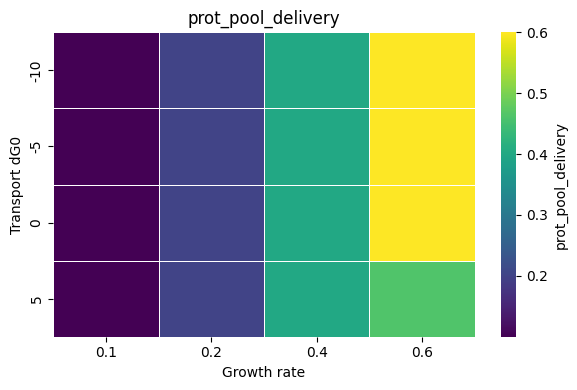

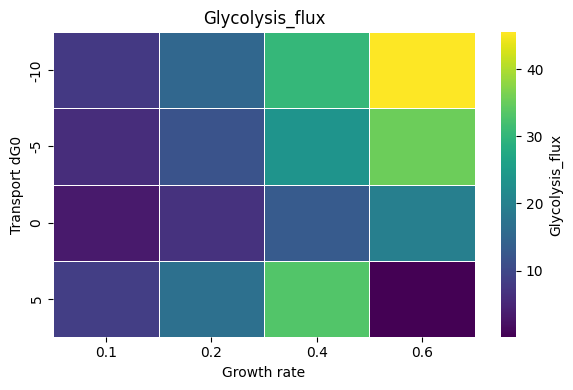

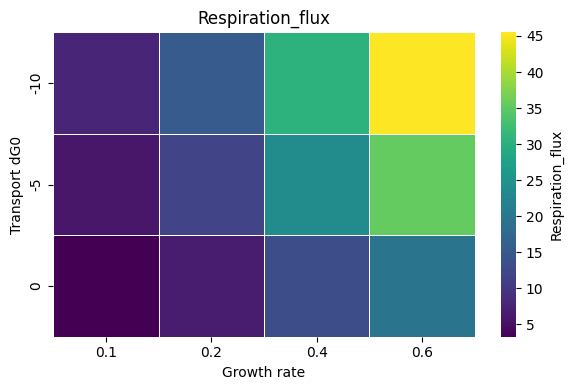

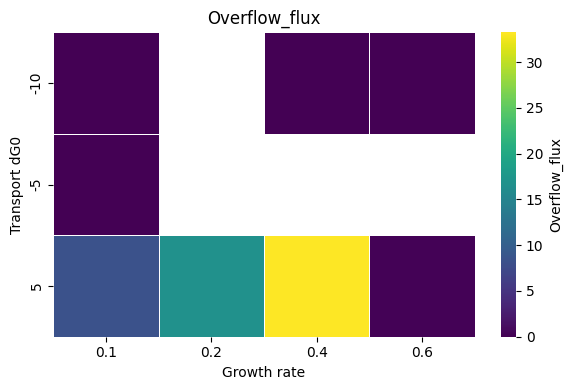

In [58]:
plot_enzyme_heatmaps(
    df_for_plot,
    variables=[
        "prot_pool_delivery",
        "Glycolysis_flux",
        "Respiration_flux",
        "Overflow_flux"
    ]
)

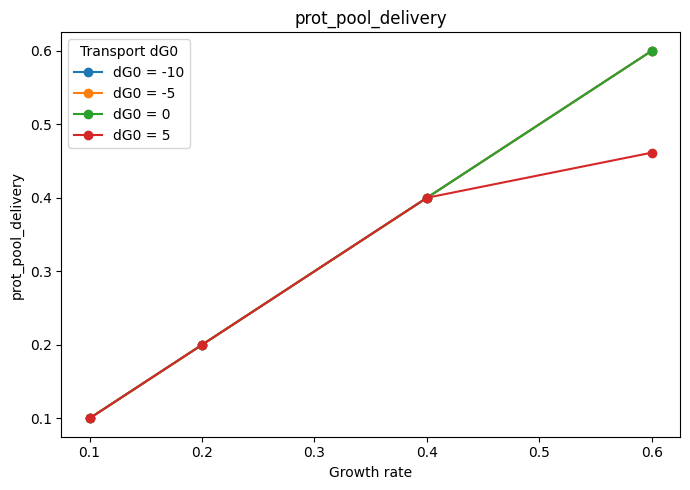

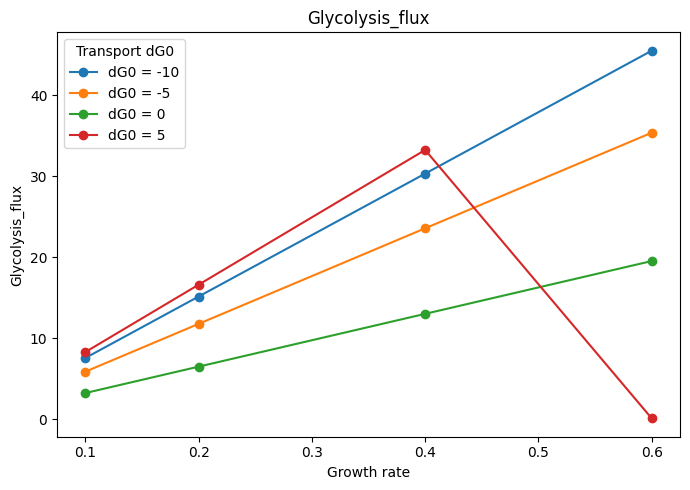

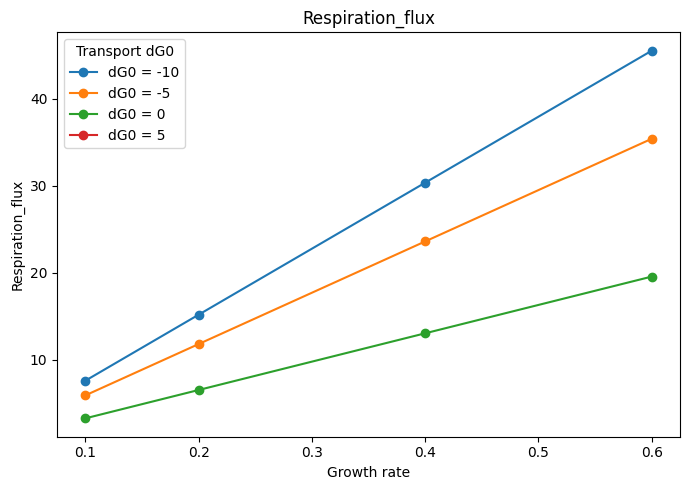

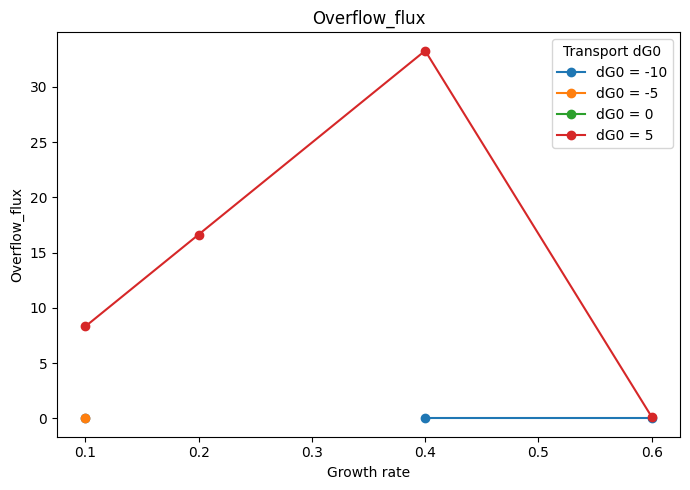

In [60]:
plot_enzyme_lines(
    df_for_plot,
    variables=[
        "prot_pool_delivery",
        "Glycolysis_flux",
        "Respiration_flux",
        "Overflow_flux"
    ]
)

## Save results to pickle

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

results_to_save = {
    'metadata': {
        'created': timestamp,
        'objective_target': objective_target,
        'objective_sense': objective_sense,
        'growth_grid': growth_grid,
        'dG0_transport_values': dG0_transport_values,
        'pop_size': pop_size,
        'evolution_num_gens': evolution_num_gens,
        'kcat': kcat,
        'total_runs': total_runs,
    },
    'all_results': {
        'comp_noATP': dict(results_grid1),
        'comp_ATP': dict(results_grid1_w_constraint),
        'nocomp_ATP': dict(results_grid1_wo),
        'nocomp_noATP': dict(results_grid1_wo_wo_atpconstraint),
    },
    'df_all': df_all,
    'advantage_df': adv_df,
}

pkl_path = f'dG0_growth_atp_consumption_results_{timestamp}.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(results_to_save, f)
print(f"Saved results to: {pkl_path}")


Saved results to: dG0_growth_sweep_results_20260610_125148.pkl
